In [1]:
import pandas as pd
import numpy as np

reg = pd.read_csv("regular_season_raw.csv")

def add_features(df):
    df = df.copy()
    hours = df["timeOnIce"] / 3600
    df["pos_group"] = df["positionCode"].map({"C": "F", "L": "F", "R": "F", "D": "D"})
    df["pp_share"]  = df["ppTimeOnIce"] / df["timeOnIce"]
    df["pk_share"]  = df["shTimeOnIce"] / df["timeOnIce"]
    for stat, col in [("goals", "goals"), ("assists", "assists"), ("shots", "shots"),
                      ("hits", "hits"), ("pim", "penaltyMinutes"), ("blocks", "blockedShots")]:
        df[f"{stat}_per60"] = df[col] / hours
    return df

features = ["height", "weight", "pp_share", "pk_share", "goals_per60", "assists_per60",
            "shots_per60", "hits_per60", "pim_per60", "blocks_per60"]

reg = add_features(reg)
reg["meets_cutoff"] = reg["gamesPlayed"] >= 20
print(reg.shape)

(18853, 43)


In [2]:
base  = reg[reg["meets_cutoff"]]
means = base.groupby(["seasonId", "pos_group"])[features].mean()
sds   = base.groupby(["seasonId", "pos_group"])[features].std()

keys  = pd.MultiIndex.from_frame(reg[["seasonId", "pos_group"]])
zcols = [f"z_{f}" for f in features]
reg[zcols] = (reg[features].to_numpy() - means.loc[keys].to_numpy()) / sds.loc[keys].to_numpy()

cut = reg[reg["meets_cutoff"]]
print(pd.DataFrame({
    "mean": cut[zcols].mean(),
    "std": cut[zcols].std(),
    "n_beyond_4sd": (cut[zcols].abs() > 4).sum(),
}).round(2))

                 mean  std  n_beyond_4sd
z_height          0.0  1.0             7
z_weight         -0.0  1.0             4
z_pp_share        0.0  1.0             1
z_pk_share       -0.0  1.0             1
z_goals_per60    -0.0  1.0            15
z_assists_per60   0.0  1.0            13
z_shots_per60    -0.0  1.0             7
z_hits_per60      0.0  1.0            60
z_pim_per60      -0.0  1.0           167
z_blocks_per60    0.0  1.0            36


Values beyond ±4 after capping: 0
Forwards used to build clusters: 9325 

      inertia  silhouette  calinski_harabasz
k                                           
2   65935.926       0.243           3392.441
3   57299.908       0.231           2654.145
4   51154.115       0.186           2355.089
5   47405.544       0.167           2090.035
6   44879.337       0.142           1870.862
7   42934.459       0.141           1699.852
8   41300.545       0.123           1567.146
9   40015.898       0.123           1452.510
10  38814.290       0.120           1362.987


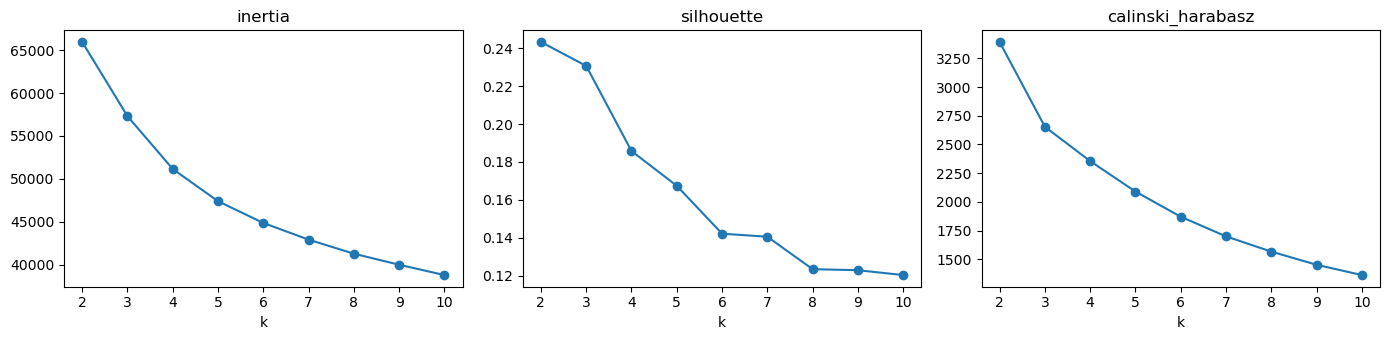

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.pyplot as plt

reg[zcols] = reg[zcols].clip(-4, 4)
print("Values beyond ±4 after capping:", int((reg[zcols].abs() > 4).sum().sum()))

Xf = reg.loc[reg["meets_cutoff"] & (reg["pos_group"] == "F"), zcols].to_numpy()
print("Forwards used to build clusters:", len(Xf), "\n")

results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xf)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Xf, km.labels_, sample_size=4000, random_state=42),
        "calinski_harabasz": calinski_harabasz_score(Xf, km.labels_),
    })
res_f = pd.DataFrame(results).set_index("k")
print(res_f.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, res_f.columns):
    ax.plot(res_f.index, res_f[col], marker="o")
    ax.set_title(col)
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()

In [4]:
fwd = reg[reg["meets_cutoff"] & (reg["pos_group"] == "F")].copy()

def profile(df, X, k):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    df = df.assign(cluster=km.labels_)
    prof = df.groupby("cluster")[features].mean().round(2)
    prof.insert(0, "n_players", df["cluster"].value_counts().sort_index())
    prof["examples_2023_24"] = (df[df["seasonId"] == 20232024]
        .sort_values("points", ascending=False)
        .groupby("cluster")["skaterFullName"]
        .apply(lambda s: ", ".join(s.head(3))))
    return prof

for k in [3, 4, 5]:
    print(f"\n===== k = {k} =====")
    display(profile(fwd, Xf, k))


===== k = 3 =====


,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,1333,74.56,217.44,0.03,0.03,0.51,0.63,6.13,12.46,8.47,2.00,"Evander Kane, Trent Frederic, Anders Lee"
1,4880,72.67,199.41,0.15,0.03,0.97,1.32,8.10,3.31,1.73,1.45,"Nikita Kucherov, Nathan MacKinnon, Connor McDavid"
2,3112,72.61,197.23,0.04,0.12,0.52,0.73,5.83,5.78,2.08,2.50,"Charlie Coyle, Adam Henrique, J.T. Compher"



===== k = 4 =====


,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,2436,74.19,211.13,0.15,0.03,1.08,1.33,8.67,3.88,1.92,1.48,"Nathan MacKinnon, Connor McDavid, Artemi Panarin"
1,1137,74.36,216.70,0.02,0.03,0.48,0.61,5.98,13.22,9.42,2.02,"Trent Frederic, Tom Wilson, Matthew Knies"
2,2826,72.86,199.00,0.03,0.12,0.51,0.71,5.80,6.05,2.15,2.58,"Adam Henrique, J.T. Compher, Phillip Danault"
3,2926,71.36,189.22,0.13,0.03,0.82,1.25,7.37,3.12,1.61,1.48,"Nikita Kucherov, Brayden Point, Sebastian Aho"



===== k = 5 =====


,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,804,74.30,217.36,0.02,0.03,0.44,0.56,5.67,14.62,11.73,2.12,"Dakota Joshua, Jack McBain, Martin Pospisil"
1,2527,71.22,188.34,0.13,0.04,0.79,1.23,7.16,3.04,1.59,1.52,"Mitch Marner, Jesper Bratt, Vincent Trocheck"
2,2304,72.58,197.17,0.03,0.13,0.48,0.69,5.65,6.22,2.26,2.71,"Adam Henrique, Anthony Cirelli, Alexander Kerfoot"
3,1892,74.48,212.69,0.09,0.05,0.72,0.90,7.03,5.98,2.32,1.75,"Anze Kopitar, Charlie Coyle, Alex Tuch"
4,1798,73.48,205.43,0.17,0.03,1.22,1.52,9.40,3.14,1.76,1.36,"Nikita Kucherov, Nathan MacKinnon, Connor McDavid"


In [5]:
km_f = KMeans(n_clusters=5, n_init=20, random_state=42).fit(Xf)
names_f = {0: "Physical", 1: "Small skilled", 2: "Defensive/PK", 3: "Big two-way", 4: "Elite scorer"}
fwd["type"] = pd.Series(km_f.labels_, index=fwd.index).map(names_f)

# Check 0: labels line up with the profile table
print(fwd.groupby("type")[["height", "goals_per60", "hits_per60", "pk_share"]].mean().round(2), "\n")

# Check 1: the 8 most typical players in each cluster (closest to its center)
dist = km_f.transform(Xf)
fwd["dist_to_center"] = dist[np.arange(len(fwd)), km_f.labels_]
display(fwd.sort_values("dist_to_center").groupby("type").head(8)
           .sort_values(["type", "dist_to_center"])
           [["type", "skaterFullName", "seasonId", "teamAbbrevs", "gamesPlayed", "points", "hits", "penaltyMinutes"]])

# Check 2: well-known players, number of seasons in each type
known = ["Sidney Crosby", "Alex Ovechkin", "Patrice Bergeron", "Brad Marchand", "Ryan Reaves",
         "Tom Wilson", "Johnny Gaudreau", "Anze Kopitar", "Matthew Tkachuk", "Jordan Staal"]
display(pd.crosstab(fwd.loc[fwd["skaterFullName"].isin(known), "skaterFullName"],
                    fwd.loc[fwd["skaterFullName"].isin(known), "type"]))

               height  goals_per60  hits_per60  pk_share
type                                                    
Big two-way     74.48         0.72        5.98      0.05
Defensive/PK    72.58         0.48        6.22      0.13
Elite scorer    73.48         1.22        3.14      0.03
Physical        74.30         0.44       14.62      0.03
Small skilled   71.22         0.79        3.04      0.04 



,type,skaterFullName,seasonId,teamAbbrevs,gamesPlayed,points,hits,penaltyMinutes
4818,Big two-way,Rostislav Olesz,20102011,FLA,44,17,68,8
12566,Big two-way,Charlie Coyle,20192020,BOS,70,37,83,21
16698,Big two-way,Jesperi Kotkaniemi,20232024,CAR,79,27,56,36
7004,Big two-way,Olli Jokinen,20132014,WPG,82,43,120,62
1691,Big two-way,Rene Bourque,20062007,CHI,44,17,55,38
2214,Big two-way,Joel Perrault,20072008,PHX,49,17,42,48
14773,Big two-way,Taylor Raddysh,20212022,"TBL,CHI",74,22,103,10
7683,Big two-way,Charlie Coyle,20132014,MIN,70,30,108,33
4014,Defensive/PK,Petteri Nokelainen,20092010,"ANA,PHX",67,13,80,27
4470,Defensive/PK,Tom Kostopoulos,20102011,"CAR,CGY",76,18,122,74


type,Big two-way,Defensive/PK,Elite scorer,Physical,Small skilled
skaterFullName,,,,,
Alex Ovechkin,0,0,21,0,0
Anze Kopitar,12,0,8,0,0
Brad Marchand,0,1,4,0,12
Johnny Gaudreau,0,0,0,0,10
Jordan Staal,20,0,0,0,0
Matthew Tkachuk,0,0,10,0,0
Patrice Bergeron,0,0,12,0,5
Ryan Reaves,0,0,0,16,0
Sidney Crosby,0,0,21,0,0


In [6]:
# Combined size feature: average of the height and weight z-scores, re-standardized
reg["size_raw"] = reg[["z_height", "z_weight"]].mean(axis=1)
base = reg[reg["meets_cutoff"]]
m  = base.groupby(["seasonId", "pos_group"])["size_raw"].mean()
sd = base.groupby(["seasonId", "pos_group"])["size_raw"].std()
reg["z_size"] = ((reg["size_raw"] - m.loc[keys].to_numpy()) / sd.loc[keys].to_numpy()).clip(-4, 4)

fwd_cut = reg["meets_cutoff"] & (reg["pos_group"] == "F")
print("Height-weight correlation (forwards):",
      round(reg.loc[fwd_cut, ["height", "weight"]].corr().iloc[0, 1], 2))

zcols2 = ["z_size"] + [c for c in zcols if c not in ("z_height", "z_weight")]
fwd2 = reg[fwd_cut].copy()
Xf2 = fwd2[zcols2].to_numpy()

km_f2 = KMeans(n_clusters=5, n_init=20, random_state=42).fit(Xf2)
fwd2["cluster"] = km_f2.labels_
print("Silhouette, k = 5:",
      round(silhouette_score(Xf2, km_f2.labels_, sample_size=4000, random_state=42), 3), "(was 0.167)\n")

# New cluster profiles (real stats, 2023-24 examples)
display(profile(fwd2, Xf2, 5))

# Well-known players under the new clustering
look = fwd2["skaterFullName"].isin(known + ["Nikita Kucherov", "Mitch Marner"])
display(pd.crosstab(fwd2.loc[look, "skaterFullName"], fwd2.loc[look, "cluster"]))

# How the old types map onto the new clusters
display(pd.crosstab(fwd["type"], fwd2["cluster"]))

Height-weight correlation (forwards): 0.72
Silhouette, k = 5: 0.167 (was 0.167)



,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,2173,72.74,198.38,0.03,0.14,0.49,0.69,5.60,6.25,2.27,2.77,"Adam Henrique, Anthony Cirelli, Alexander Kerfoot"
1,2020,73.36,204.64,0.17,0.03,1.22,1.49,9.39,3.23,1.79,1.36,"Nikita Kucherov, Nathan MacKinnon, Connor McDavid"
2,1933,73.87,208.37,0.07,0.04,0.67,0.80,7.06,6.80,2.53,1.78,"Charlie Coyle, Blake Coleman, Juraj Slafkovský"
3,712,74.26,217.23,0.02,0.02,0.42,0.55,5.57,14.92,12.69,2.11,"Martin Pospisil, Michael McCarron, Will Cuylle"
4,2487,71.60,190.93,0.14,0.04,0.77,1.27,6.88,2.76,1.49,1.53,"Robert Thomas, Mitch Marner, Vincent Trocheck"


cluster,0,1,2,3,4
skaterFullName,,,,,
Alex Ovechkin,0,21,0,0,0
Anze Kopitar,0,9,2,0,9
Brad Marchand,1,8,0,0,8
Johnny Gaudreau,0,2,0,0,8
Jordan Staal,6,1,13,0,0
Matthew Tkachuk,0,10,0,0,0
Mitch Marner,0,3,0,0,7
Nikita Kucherov,0,11,0,0,1
Patrice Bergeron,0,11,0,0,6


cluster,0,1,2,3,4
type,,,,,
Big two-way,72,137,1464,0,219
Defensive/PK,2064,0,193,12,35
Elite scorer,0,1707,2,0,89
Physical,26,0,80,698,0
Small skilled,11,176,194,2,2144


type
Skilled playmaker    2487
Defensive/PK         2173
Top-line scorer      2020
Power forward        1933
Physical              712
Name: count, dtype: int64 

Defensemen used to build clusters: 4902 

      inertia  silhouette  calinski_harabasz
k                                           
2   30343.890       0.258           2008.234
3   26714.003       0.181           1473.163
4   24362.213       0.153           1234.304
5   22754.962       0.153           1077.384
6   21625.682       0.136            957.872
7   20641.185       0.129            875.039
8   19868.513       0.119            806.225
9   19176.483       0.122            752.828
10  18614.740       0.113            705.636


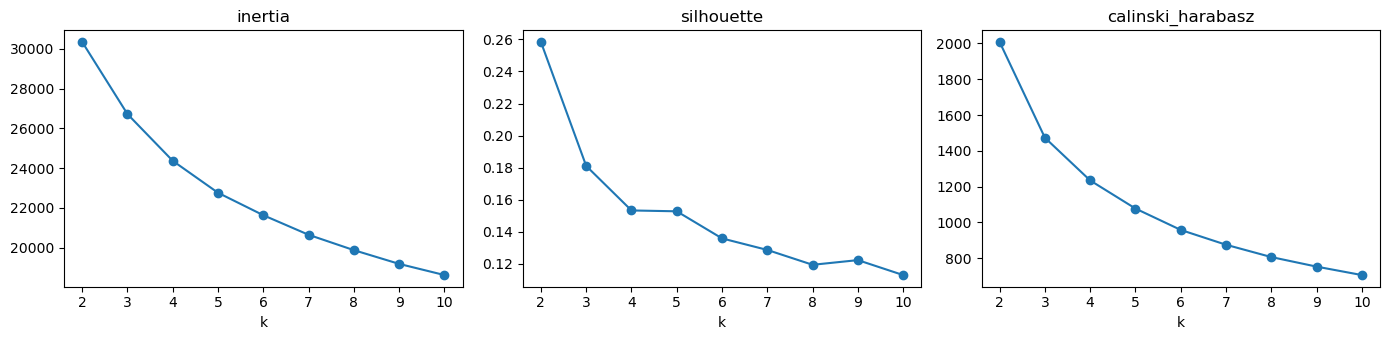

In [7]:
names_f2 = {0: "Defensive/PK", 1: "Top-line scorer", 2: "Power forward",
            3: "Physical", 4: "Skilled playmaker"}
fwd2["type"] = fwd2["cluster"].map(names_f2)
print(fwd2["type"].value_counts(), "\n")

d_cut = reg["meets_cutoff"] & (reg["pos_group"] == "D")
dmen = reg[d_cut].copy()
Xd = dmen[zcols2].to_numpy()
print("Defensemen used to build clusters:", len(Xd), "\n")

results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xd)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(Xd, km.labels_, sample_size=4000, random_state=42),
        "calinski_harabasz": calinski_harabasz_score(Xd, km.labels_),
    })
res_d = pd.DataFrame(results).set_index("k")
print(res_d.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, res_d.columns):
    ax.plot(res_d.index, res_d[col], marker="o")
    ax.set_title(col)
    ax.set_xlabel("k")
plt.tight_layout()
plt.show()

In [8]:
for k in [3, 4, 5]:
    print(f"\n===== k = {k} =====")
    display(profile(dmen, Xd, k))


===== k = 3 =====


,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,2056,73.53,203.73,0.04,0.10,0.14,0.59,3.47,3.44,1.51,4.64,"Cam Fowler, Jaccob Slavin, Owen Power"
1,1191,75.31,219.09,0.01,0.11,0.13,0.48,3.43,7.40,3.45,5.15,"Darnell Nurse, Tyler Myers, Jake McCabe"
2,1655,73.26,203.69,0.13,0.06,0.33,1.04,5.38,2.96,1.57,3.62,"Quinn Hughes, Cale Makar, Roman Josi"



===== k = 4 =====


,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,1470,74.35,210.26,0.02,0.13,0.13,0.53,3.20,4.19,1.65,5.41,"Moritz Seider, Ivan Provorov, Ryan McDonagh"
1,1234,73.50,205.42,0.14,0.07,0.37,1.12,5.67,2.88,1.57,3.64,"Quinn Hughes, Cale Makar, Roman Josi"
2,1417,72.87,199.62,0.06,0.06,0.17,0.68,4.00,3.29,1.57,3.87,"Filip Hronek, Cam Fowler, Jaccob Slavin"
3,781,75.36,219.58,0.01,0.10,0.13,0.48,3.54,8.19,4.12,4.78,"Darnell Nurse, Tyler Myers, Jake McCabe"



===== k = 5 =====


,n_players,height,weight,pp_share,pk_share,goals_per60,assists_per60,shots_per60,hits_per60,pim_per60,blocks_per60,examples_2023_24
cluster,,,,,,,,,,,,
0,695,75.29,218.25,0.11,0.09,0.36,0.92,5.70,3.72,1.80,4.12,"Victor Hedman, Rasmus Dahlin, MacKenzie Weegar"
1,1408,74.33,209.94,0.02,0.13,0.12,0.52,3.13,4.19,1.65,5.42,"Ivan Provorov, Ryan McDonagh, Dylan DeMelo"
2,1254,72.79,198.96,0.06,0.06,0.16,0.66,3.88,3.33,1.60,3.87,"Cam Fowler, Neal Pionk, Darren Raddysh"
3,796,72.19,195.87,0.15,0.05,0.34,1.20,5.41,2.42,1.40,3.42,"Quinn Hughes, Cale Makar, Roman Josi"
4,749,75.30,219.26,0.01,0.10,0.12,0.47,3.46,8.28,4.17,4.81,"Tyler Myers, Jake McCabe, William Borgen"


In [9]:
km_d = KMeans(n_clusters=4, n_init=20, random_state=42).fit(Xd)
names_d = {0: "Shutdown/PK", 1: "Offensive", 2: "Two-way/depth", 3: "Physical"}
dmen["type"] = pd.Series(km_d.labels_, index=dmen.index).map(names_d)

# Check 0: labels line up with the k = 4 profile table
print(dmen.groupby("type")[["height", "pp_share", "pk_share", "assists_per60",
                            "hits_per60", "blocks_per60"]].mean().round(2), "\n")

# Check 1: the 8 most typical defensemen in each type (closest to its center)
dist_d = km_d.transform(Xd)
dmen["dist_to_center"] = dist_d[np.arange(len(dmen)), km_d.labels_]
display(dmen.sort_values("dist_to_center").groupby("type").head(8)
            .sort_values(["type", "dist_to_center"])
            [["type", "skaterFullName", "seasonId", "teamAbbrevs", "gamesPlayed",
              "points", "hits", "blockedShots", "penaltyMinutes"]])

# Check 2: well-known defensemen, number of seasons in each type
known_d = ["Jaccob Slavin", "Marc-Edouard Vlasic", "Zdeno Chara", "Brooks Orpik", "Radko Gudas",
           "Erik Karlsson", "Cale Makar", "Victor Hedman", "Drew Doughty", "Shea Weber",
           "Duncan Keith", "Ryan Suter"]
look_d = dmen["skaterFullName"].isin(known_d)
display(pd.crosstab(dmen.loc[look_d, "skaterFullName"], dmen.loc[look_d, "type"]))

               height  pp_share  pk_share  assists_per60  hits_per60  \
type                                                                   
Offensive       73.50      0.14      0.07           1.12        2.88   
Physical        75.36      0.01      0.10           0.48        8.19   
Shutdown/PK     74.35      0.02      0.13           0.53        4.19   
Two-way/depth   72.87      0.06      0.06           0.68        3.29   

               blocks_per60  
type                         
Offensive              3.64  
Physical               4.78  
Shutdown/PK            5.41  
Two-way/depth          3.87   



,type,skaterFullName,seasonId,teamAbbrevs,gamesPlayed,points,hits,blockedShots,penaltyMinutes
125,Offensive,Roman Hamrlik,20052006,CGY,51,26,54,63,56
5489,Offensive,Dennis Wideman,20112012,WSH,82,46,113,132,46
15265,Offensive,Justin Faulk,20222023,STL,82,50,112,140,34
9889,Offensive,P.K. Subban,20162017,NSH,66,40,78,104,44
2990,Offensive,Christian Ehrhoff,20082009,SJS,77,42,79,90,63
3244,Offensive,Alexander Edler,20082009,VAN,80,37,102,93,54
461,Offensive,Jaroslav Spacek,20052006,"CHI,EDM",76,43,88,99,96
15361,Offensive,Mike Matheson,20222023,MTL,48,34,53,80,33
509,Physical,Mike Commodore,20052006,CAR,72,13,125,90,138
9200,Physical,Brayden McNabb,20152016,LAK,81,14,206,95,92


type,Offensive,Physical,Shutdown/PK,Two-way/depth
skaterFullName,,,,
Brooks Orpik,0,9,5,0
Cale Makar,7,0,0,0
Drew Doughty,15,0,0,3
Duncan Keith,9,0,1,7
Erik Karlsson,16,0,0,0
Jaccob Slavin,0,0,6,5
Marc-Edouard Vlasic,1,0,10,8
Radko Gudas,0,14,0,0
Ryan Suter,8,0,1,11


In [10]:
f_all = reg["pos_group"].eq("F")
types_f = pd.Series(km_f2.predict(reg.loc[f_all, zcols2].to_numpy()),
                    index=reg.index[f_all]).map(names_f2)
types_d = pd.Series(km_d.predict(reg.loc[~f_all, zcols2].to_numpy()),
                    index=reg.index[~f_all]).map(names_d)
reg["type"] = pd.concat([types_f, types_d])

# Check: players who built the clusters should keep the same type
print("Forwards agreeing with fitted types:", round((reg.loc[fwd2.index, "type"] == fwd2["type"]).mean(), 4))
print("Defensemen agreeing with fitted types:", round((reg.loc[dmen.index, "type"] == dmen["type"]).mean(), 4))
print("Player-seasons with no type:", int(reg["type"].isna().sum()), "\n")

print(pd.crosstab(reg["type"], reg["meets_cutoff"], margins=True))

reg[["playerId", "seasonId", "skaterFullName", "pos_group", "gamesPlayed",
     "meets_cutoff", "type"]].to_csv("player_types.csv", index=False)

Forwards agreeing with fitted types: 1.0
Defensemen agreeing with fitted types: 1.0
Player-seasons with no type: 0 

meets_cutoff       False   True    All
type                                  
Defensive/PK         711   2173   2884
Offensive            145   1234   1379
Physical            1017   1493   2510
Power forward       1106   1933   3039
Shutdown/PK          305   1470   1775
Skilled playmaker    464   2487   2951
Top-line scorer      169   2020   2189
Two-way/depth        709   1417   2126
All                 4626  14227  18853


In [11]:
import os
os.makedirs("paper_outputs", exist_ok=True)

def type_table(df, order):
    t = df.groupby("type").agg(
        n=("type", "size"), height=("height", "mean"), weight=("weight", "mean"),
        pp=("pp_share", "mean"), pk=("pk_share", "mean"),
        g60=("goals_per60", "mean"), a60=("assists_per60", "mean"), s60=("shots_per60", "mean"),
        h60=("hits_per60", "mean"), pim60=("pim_per60", "mean"), b60=("blocks_per60", "mean"))
    t.insert(1, "pct", t["n"] / t["n"].sum() * 100)
    t[["pp", "pk"]] = t[["pp", "pk"]] * 100

    cnt = df.groupby(["type", "skaterFullName"]).size().rename("seasons").reset_index()
    cnt = cnt.sort_values(["type", "seasons"], ascending=[True, False]).groupby("type").head(3)
    cnt["label"] = cnt["skaterFullName"] + " (" + cnt["seasons"].astype(str) + ")"
    t["examples"] = cnt.groupby("type")["label"].agg(", ".join)

    t = t.loc[order].round(2)
    t.columns = ["Player-seasons", "% of position", "Height (in)", "Weight (lb)", "PP share (%)",
                 "PK share (%)", "Goals/60", "Assists/60", "Shots/60", "Hits/60", "PIM/60",
                 "Blocks/60", "Most frequent members (seasons in type)"]
    t.index.name = "Type"
    return t

table1 = type_table(fwd2, ["Top-line scorer", "Skilled playmaker", "Power forward", "Defensive/PK", "Physical"])
table2 = type_table(dmen, ["Offensive", "Shutdown/PK", "Two-way/depth", "Physical"])

table1.to_csv("paper_outputs/table1_forward_types.csv")
table2.to_csv("paper_outputs/table2_defense_types.csv")
display(table1)
display(table2)

,Player-seasons,% of position,Height (in),Weight (lb),PP share (%),PK share (%),Goals/60,Assists/60,Shots/60,Hits/60,PIM/60,Blocks/60,Most frequent members (seasons in type)
Type,,,,,,,,,,,,,
Top-line scorer,2020,21.66,73.36,204.64,16.95,2.96,1.22,1.49,9.39,3.23,1.79,1.36,"Alex Ovechkin (21), Sidney Crosby (21), Evgeni..."
Skilled playmaker,2487,26.67,71.60,190.93,13.71,4.11,0.77,1.27,6.88,2.76,1.49,1.53,"Paul Stastny (17), David Krejci (15), Marcus J..."
Power forward,1933,20.73,73.87,208.37,7.18,3.88,0.67,0.80,7.06,6.80,2.53,1.78,"Jordan Staal (13), Nick Foligno (12), David Ba..."
Defensive/PK,2173,23.30,72.74,198.38,2.54,14.22,0.49,0.69,5.60,6.25,2.27,2.77,"Casey Cizikas (14), Nate Thompson (14), Luke G..."
Physical,712,7.64,74.26,217.23,1.61,2.39,0.42,0.55,5.57,14.92,12.69,2.11,"Ryan Reaves (16), Matt Martin (15), Chris Neil..."


,Player-seasons,% of position,Height (in),Weight (lb),PP share (%),PK share (%),Goals/60,Assists/60,Shots/60,Hits/60,PIM/60,Blocks/60,Most frequent members (seasons in type)
Type,,,,,,,,,,,,,
Offensive,1234,25.17,73.50,205.42,13.73,6.57,0.37,1.12,5.67,2.88,1.57,3.64,"Brent Burns (20), Kris Letang (17), Erik Karls..."
Shutdown/PK,1470,29.99,74.35,210.26,1.93,12.89,0.13,0.53,3.20,4.19,1.65,5.41,"Chris Tanev (14), Marc Staal (14), Josh Gorges..."
Two-way/depth,1417,28.91,72.87,199.62,6.28,6.48,0.17,0.68,4.00,3.29,1.57,3.87,"Dmitry Orlov (12), Andrej Sekera (11), Dan Ham..."
Physical,781,15.93,75.36,219.58,1.17,9.82,0.13,0.48,3.54,8.19,4.12,4.78,"Luke Schenn (17), Brenden Dillon (14), Radko G..."


      inertia  silhouette  calinski_harabasz
k                                           
2   56820.733       0.266           3910.007
3   48976.813       0.255           3014.351
4   43872.426       0.175           2604.621
5   40844.231       0.167           2270.819
6   38687.403       0.155           2021.645
7   36799.743       0.142           1850.593
8   35278.579       0.134           1711.827
9   34175.510       0.130           1583.613
10  33134.485       0.125           1484.245


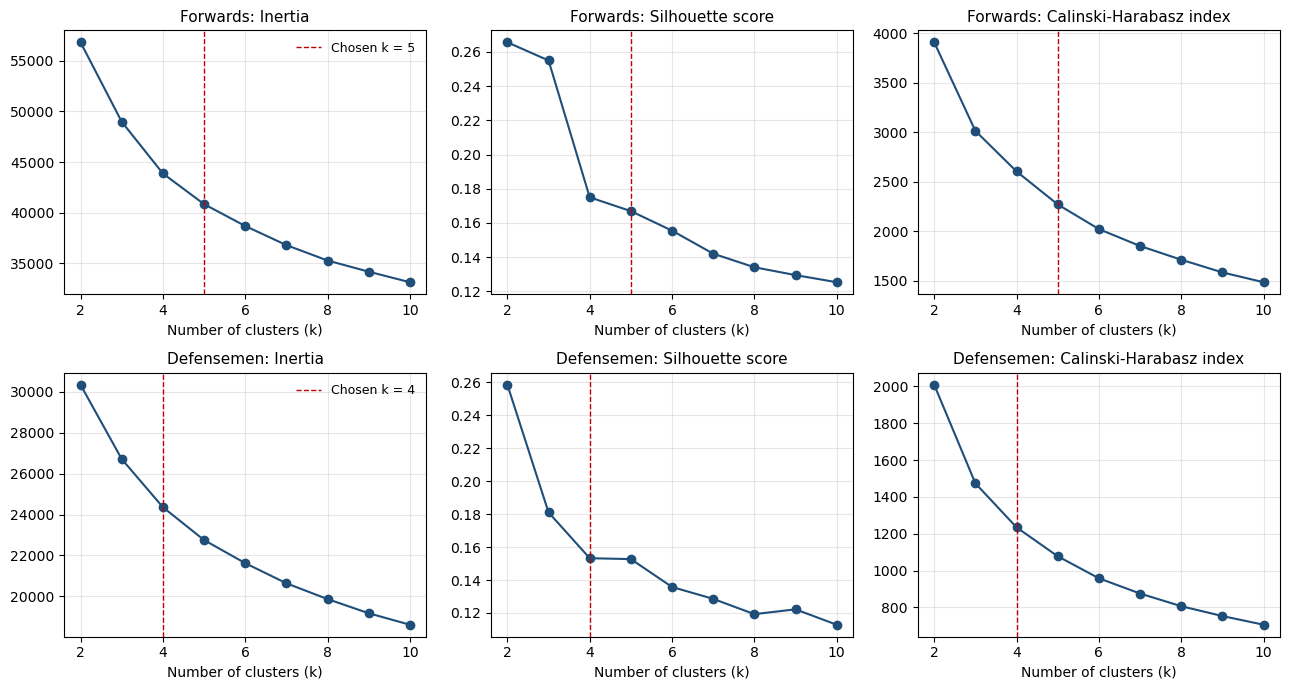

In [12]:
# Rerun forward k-selection with the FINAL 9 features (combined size)
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(Xf2)
    results.append({"k": k, "inertia": km.inertia_,
                    "silhouette": silhouette_score(Xf2, km.labels_, sample_size=4000, random_state=42),
                    "calinski_harabasz": calinski_harabasz_score(Xf2, km.labels_)})
res_f2 = pd.DataFrame(results).set_index("k")
print(res_f2.round(3))

# Figure 1: choosing k for forwards and defensemen
titles = {"inertia": "Inertia", "silhouette": "Silhouette score", "calinski_harabasz": "Calinski-Harabasz index"}
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for row, (res, label, k_chosen) in enumerate([(res_f2, "Forwards", 5), (res_d, "Defensemen", 4)]):
    for col, metric in enumerate(titles):
        ax = axes[row, col]
        ax.plot(res.index, res[metric], marker="o", color="#1f4e79")
        ax.axvline(k_chosen, color="#c00000", linestyle="--", linewidth=1, label=f"Chosen k = {k_chosen}")
        ax.set_title(f"{label}: {titles[metric]}", fontsize=11)
        ax.set_xlabel("Number of clusters (k)")
        ax.grid(alpha=0.3)
        if col == 0:
            ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("paper_outputs/figure1_choosing_k.png", dpi=300, bbox_inches="tight")
plt.show()